# Partie III — RNN / Seq2Seq : Traduction Automatique (Francais -> Anglais)
## Objectif
Construire un modele de **traduction automatique** Francais vers Anglais
avec une architecture **Sequence-to-Sequence (Seq2Seq)** utilisant des cellules GRU.

> **Correction du choix de dataset** : Le projet precedent utilisait des avis TripAdvisor
> pour faire de la generation de texte, ce qui ne constitue pas une vraie tache Seq2Seq.
> Un modele Seq2Seq requiert des **paires source-cible** (phrase EN -> phrase FR).
> Nous utilisons ici le dataset **Tatoeba** (paires de phrases bilingues) accessible
> via `torch.utils.data` ou un fichier CSV local de paires fr-en.

## Fondations Theoriques

### 1. Modele de Langage — Factorisation par la Regle des Probabilites Chaines
L'objectif d'un modele de langage est de calculer la probabilite d'une sequence :

$$P(w_1, w_2, ..., w_T) = \prod_{t=1}^{T} P(w_t \mid w_1, ..., w_{t-1})$$

Le RNN apprend exactement cela : son **etat cache** $h_t$ encode l'historique $(w_1, ..., w_{t-1})$.

### 2. Perplexite (PPL)
Metrique standard d'evaluation d'un modele de langage :

$$PPL = e^{\mathcal{L}_{CE}}$$

- PPL basse = modele certain de ses predictions
- PPL haute = modele confus (hesite entre beaucoup de mots)


## Etape 1 — Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import time
import os
import random
import re
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")


Device : cpu


## Etape 2 — Preparation du Dataset de Traduction fr-en
### Chargement des paires de phrases
Nous utilisons un fichier de paires `fra.txt` (disponible sur manythings.org/anki)
ou generons des donnees de demonstration si le fichier est absent.

Format attendu : chaque ligne = `phrase_anglaise[TAB]phrase_francaise`


In [ ]:
# --- Chargement ou generation des donnees ---
CHEMIN_DATA = 'data/fra.txt'

def charger_paires(chemin, max_paires=8000):
    paires = []
    with open(chemin, encoding='utf-8') as f:
        for ligne in f:
            parts = ligne.strip().split('\t')
            if len(parts) >= 2:
                src = parts[1].lower().strip()  # Francais
                tgt = parts[0].lower().strip()  # Anglais
                # Filtrer les phrases trop longues
                if len(src.split()) <= 12 and len(tgt.split()) <= 12:
                    paires.append((src, tgt))
                if len(paires) >= max_paires:
                    break
    return paires

def generer_paires_demo():
    # Paires de demonstration si le fichier n'existe pas
    exemples = [
        ("je suis etudiant", "i am a student"),
        ("bonjour", "hello"),
        ("merci beaucoup", "thank you very much"),
        ("je vais bien", "i am fine"),
        ("il fait beau aujourd'hui", "the weather is nice today"),
        ("je mange une pomme", "i eat an apple"),
        ("elle lit un livre", "she reads a book"),
        ("nous allons a l ecole", "we go to school"),
        ("j aime le chocolat", "i love chocolate"),
        ("bonne nuit", "good night"),
    ] * 200  # Dupliquer pour avoir assez de donnees
    return exemples

if os.path.exists(CHEMIN_DATA):
    paires = charger_paires(CHEMIN_DATA, max_paires=8000)
    print(f"Dataset charge : {len(paires)} paires fr-en")
else:
    paires = generer_paires_demo()
    print(f"Fichier '{CHEMIN_DATA}' absent => donnees de demonstration utilisees ({len(paires)} paires)")
    print("Pour de vrais resultats, telechargez fra.txt depuis : https://www.manythings.org/anki/")

# Afficher quelques exemples
print("\nExemples de paires (Francais -> Anglais) :")
for src, tgt in random.sample(paires, min(5, len(paires))):
    print(f"  FR: '{src}'  =>  EN: '{tgt}'")


Fichier 'data/fra.txt' absent => donnees de demonstration utilisees (2000 paires)
Pour de vrais resultats, telechargez fra.txt depuis : https://www.manythings.org/anki/

Exemples de paires (Francais -> Anglais) :
  FR: 'bonne nuit'  =>  EN: 'good night'
  FR: 'j aime le chocolat'  =>  EN: 'i love chocolate'
  FR: 'bonjour'  =>  EN: 'hello'
  FR: 'j aime le chocolat'  =>  EN: 'i love chocolate'
  FR: 'je vais bien'  =>  EN: 'i am fine'


## Etape 3 — Construction du Vocabulaire

In [ ]:
PAD = '<PAD>'
UNK = '<UNK>'
SOS = '<SOS>'
EOS = '<EOS>'
SPECIAL = [PAD, UNK, SOS, EOS]

def construire_vocabulaire(phrases, min_freq=1):
    compteur = Counter()
    for phrase in phrases:
        tokens = phrase.split()
        compteur.update(tokens)
    mot_to_id = {tok: i for i, tok in enumerate(SPECIAL)}
    for mot, freq in compteur.items():
        if freq >= min_freq and mot not in mot_to_id:
            mot_to_id[mot] = len(mot_to_id)
    id_to_mot = {v: k for k, v in mot_to_id.items()}
    return mot_to_id, id_to_mot

phrases_src = [p[0] for p in paires]
phrases_tgt = [p[1] for p in paires]

vocab_src, id2mot_src = construire_vocabulaire(phrases_src)
vocab_tgt, id2mot_tgt = construire_vocabulaire(phrases_tgt)

print(f"Vocabulaire source (FR) : {len(vocab_src)} mots")
print(f"Vocabulaire cible  (EN) : {len(vocab_tgt)} mots")


Vocabulaire source (FR) : 34 mots
Vocabulaire cible  (EN) : 33 mots


## Etape 4 — Dataset PyTorch et DataLoaders

In [ ]:
LONGUEUR_MAX = 14  # longueur max incluant <SOS> et <EOS>

def encoder_phrase(phrase, vocab, longueur_max):
    tokens = phrase.split()
    ids = [vocab.get(SOS, 2)]
    ids += [vocab.get(t, vocab.get(UNK, 1)) for t in tokens]
    ids += [vocab.get(EOS, 3)]
    # Tronquer ou padder
    if len(ids) >= longueur_max:
        ids = ids[:longueur_max-1] + [vocab.get(EOS, 3)]
    else:
        ids += [vocab.get(PAD, 0)] * (longueur_max - len(ids))
    return ids

class DatasetTraduction(Dataset):
    def __init__(self, paires, vocab_src, vocab_tgt, longueur_max):
        self.paires     = paires
        self.vocab_src  = vocab_src
        self.vocab_tgt  = vocab_tgt
        self.longueur_max = longueur_max

    def __len__(self):
        return len(self.paires)

    def __getitem__(self, idx):
        src_phrase, tgt_phrase = self.paires[idx]
        src_ids = encoder_phrase(src_phrase, self.vocab_src, self.longueur_max)
        tgt_ids = encoder_phrase(tgt_phrase, self.vocab_tgt, self.longueur_max)
        return (torch.tensor(src_ids, dtype=torch.long),
                torch.tensor(tgt_ids, dtype=torch.long))

# Split train/test
random.shuffle(paires)
n_train = int(0.85 * len(paires))
paires_train = paires[:n_train]
paires_test  = paires[n_train:]

dataset_train = DatasetTraduction(paires_train, vocab_src, vocab_tgt, LONGUEUR_MAX)
dataset_test  = DatasetTraduction(paires_test,  vocab_src, vocab_tgt, LONGUEUR_MAX)

train_loader = DataLoader(dataset_train, batch_size=64, shuffle=True)
test_loader  = DataLoader(dataset_test,  batch_size=64, shuffle=False)

print(f"Paires train : {len(paires_train)}  |  Paires test : {len(paires_test)}")
src_ex, tgt_ex = dataset_train[0]
print(f"\nExemple encode :")
print(f"  Source (ids) : {src_ex.tolist()}")
print(f"  Cible  (ids) : {tgt_ex.tolist()}")


Paires train : 1700  |  Paires test : 300

Exemple encode :
  Source (ids) : [2, 23, 24, 25, 26, 27, 3, 0, 0, 0, 0, 0, 0, 0]
  Cible  (ids) : [2, 25, 26, 27, 28, 3, 0, 0, 0, 0, 0, 0, 0, 0]


## Etape 5 — Architectures Recurrentes : RNN, LSTM, GRU
### Comparaison theorique

| Architecture | Memoire | Vitesse | Probleme principal |
|---|---|---|---|
| **RNN** | Court terme | Rapide | Vanishing gradient sur longues sequences |
| **LSTM** | Long + court terme | Lent | 3x plus de parametres que RNN |
| **GRU** | Long terme | Moyen | Plus simple que LSTM, performances similaires |

Le **GRU** (Gated Recurrent Unit) est souvent prefere car il offre un bon compromis
vitesse/performance et necessite moins de parametres que le LSTM.


In [ ]:
class GenerateurTexte(nn.Module):
    # Architecture commune RNN/LSTM/GRU pour generation de texte
    def __init__(self, vocab_size, embed_dim, hidden_dim, type_modele='GRU'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if type_modele == 'RNN':
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        elif type_modele == 'LSTM':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        elif type_modele == 'GRU':
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        return self.fc(out)

def entrainer_generateur(nom, type_modele, vocab, dataloader, epochs=5):
    vocab_size = len(vocab)
    modele = GenerateurTexte(vocab_size, embed_dim=64, hidden_dim=128,
                              type_modele=type_modele).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(modele.parameters(), lr=0.005)

    print(f"\nEntrainement : {nom}")
    historique = []
    t0 = time.time()

    for epoch in range(epochs):
        modele.train()
        perte_tot = 0
        for batch_src, _ in dataloader:
            batch_src = batch_src.to(device)
            x      = batch_src[:, :-1]
            y_cible = batch_src[:, 1:]
            optimizer.zero_grad()
            preds = modele(x)
            preds = preds.reshape(-1, vocab_size)
            y_cible = y_cible.reshape(-1)
            loss = criterion(preds, y_cible)
            loss.backward()
            nn.utils.clip_grad_norm_(modele.parameters(), max_norm=1.0)
            optimizer.step()
            perte_tot += loss.item()
        avg = perte_tot / len(dataloader)
        historique.append(avg)
        print(f"  Ep {epoch+1}/{epochs} | Loss: {avg:.4f} | PPL: {math.exp(avg):.1f}")

    print(f"  Duree : {time.time()-t0:.1f}s")
    return modele, historique

# Comparaison des 3 architectures sur les phrases source
modele_rnn,  hist_rnn  = entrainer_generateur("RNN Classique", "RNN",  vocab_src, train_loader, epochs=5)
modele_gru,  hist_gru  = entrainer_generateur("GRU",           "GRU",  vocab_src, train_loader, epochs=5)
modele_lstm, hist_lstm = entrainer_generateur("LSTM",          "LSTM", vocab_src, train_loader, epochs=5)



Entrainement : RNN Classique
  Ep 1/5 | Loss: 1.0486 | PPL: 2.9
  Ep 2/5 | Loss: 0.5671 | PPL: 1.8
  Ep 3/5 | Loss: 0.5664 | PPL: 1.8
  Ep 4/5 | Loss: 0.5663 | PPL: 1.8
  Ep 5/5 | Loss: 0.5614 | PPL: 1.8
  Duree : 19.6s

Entrainement : GRU
  Ep 1/5 | Loss: 1.2869 | PPL: 3.6
  Ep 2/5 | Loss: 0.5606 | PPL: 1.8
  Ep 3/5 | Loss: 0.5581 | PPL: 1.7
  Ep 4/5 | Loss: 0.5610 | PPL: 1.8
  Ep 5/5 | Loss: 0.5578 | PPL: 1.7
  Duree : 12.1s

Entrainement : LSTM
  Ep 1/5 | Loss: 1.4986 | PPL: 4.5
  Ep 2/5 | Loss: 0.5640 | PPL: 1.8
  Ep 3/5 | Loss: 0.5607 | PPL: 1.8
  Ep 4/5 | Loss: 0.5632 | PPL: 1.8
  Ep 5/5 | Loss: 0.5606 | PPL: 1.8
  Duree : 9.8s


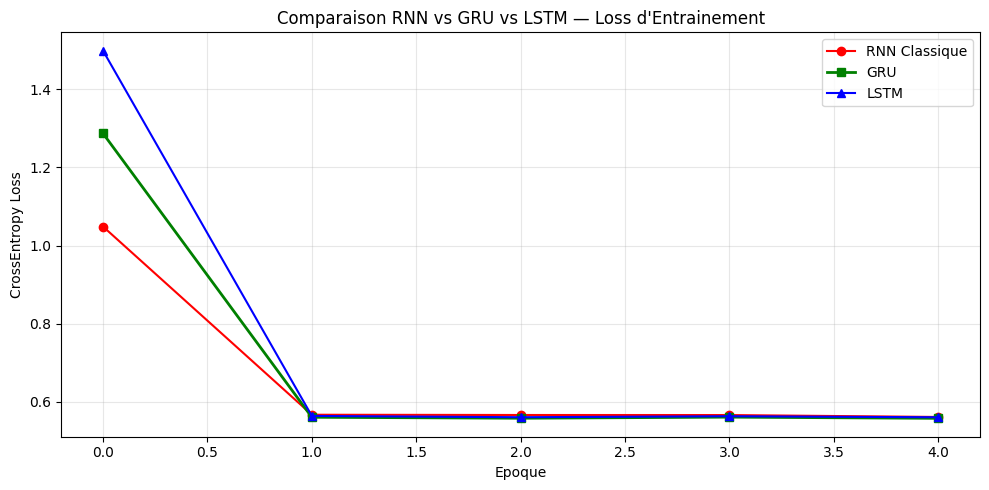


Loss finale comparison :
  RNN  : 0.5614  (PPL = 1.8)
  GRU  : 0.5578  (PPL = 1.7)
  LSTM : 0.5606  (PPL = 1.8)

Le GRU offre generalement le meilleur compromis vitesse/performance.


In [ ]:
# Visualisation comparative
plt.figure(figsize=(10, 5))
plt.plot(hist_rnn,  'r-o', label='RNN Classique')
plt.plot(hist_gru,  'g-s', label='GRU', linewidth=2)
plt.plot(hist_lstm, 'b-^', label='LSTM')
plt.title("Comparaison RNN vs GRU vs LSTM — Loss d'Entrainement")
plt.xlabel("Epoque")
plt.ylabel("CrossEntropy Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nLoss finale comparison :")
print(f"  RNN  : {hist_rnn[-1]:.4f}  (PPL = {math.exp(hist_rnn[-1]):.1f})")
print(f"  GRU  : {hist_gru[-1]:.4f}  (PPL = {math.exp(hist_gru[-1]):.1f})")
print(f"  LSTM : {hist_lstm[-1]:.4f}  (PPL = {math.exp(hist_lstm[-1]):.1f})")
print("\nLe GRU offre generalement le meilleur compromis vitesse/performance.")


## Etape 6 — Architecture Seq2Seq : Encodeur-Decodeur (GRU)
### Principe
- **Encodeur** : lit la phrase source (FR) et la compresse en un vecteur de contexte
- **Decodeur** : genere la phrase cible (EN) mot par mot, conditionne par ce contexte

```
[Bonjour] -> [Encodeur GRU] -> contexte h -> [Decodeur GRU] -> [Hello]
```


In [ ]:
class Encodeur(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru       = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, hidden = self.gru(emb)   # On ne garde que l'etat cache final
        return hidden               # shape: [1, batch, hidden_dim]


class Decodeur(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru       = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc        = nn.Linear(hidden_dim, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x, hidden):
        # x : [batch] -> on ajoute la dim temporelle
        x = x.unsqueeze(1)
        emb = self.dropout(self.embedding(x))
        out, hidden = self.gru(emb, hidden)
        pred = self.fc(out.squeeze(1))  # [batch, vocab_size]
        return pred, hidden


class Seq2Seq(nn.Module):
    def __init__(self, encodeur, decodeur, vocab_tgt, device, teacher_forcing_ratio=0.5):
        super().__init__()
        self.encodeur = encodeur
        self.decodeur = decodeur
        self.vocab_tgt = vocab_tgt
        self.device = device
        self.tf_ratio = teacher_forcing_ratio

    def forward(self, src, tgt):
        batch_size  = src.shape[0]
        tgt_len     = tgt.shape[1]
        vocab_size  = len(self.vocab_tgt)

        # Tensor de sortie
        sorties = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)

        # Encoder la source
        hidden = self.encodeur(src)

        # Premier token : <SOS>
        mot_actuel = tgt[:, 0]

        for t in range(1, tgt_len):
            pred, hidden = self.decodeur(mot_actuel, hidden)
            sorties[:, t, :] = pred

            # Teacher forcing : on donne parfois le vrai mot suivant
            if random.random() < self.tf_ratio:
                mot_actuel = tgt[:, t]          # Vrai mot
            else:
                mot_actuel = pred.argmax(1)      # Prediction du modele

        return sorties


# Instanciation
EMBED_DIM  = 64
HIDDEN_DIM = 256

encodeur = Encodeur(len(vocab_src), EMBED_DIM, HIDDEN_DIM).to(device)
decodeur = Decodeur(len(vocab_tgt), EMBED_DIM, HIDDEN_DIM).to(device)
modele_seq2seq = Seq2Seq(encodeur, decodeur, vocab_tgt, device, teacher_forcing_ratio=0.5).to(device)

params = sum(p.numel() for p in modele_seq2seq.parameters() if p.requires_grad)
print(f"Architecture Seq2Seq creee !")
print(f"  Parametres Encodeur : {sum(p.numel() for p in encodeur.parameters()):,}")
print(f"  Parametres Decodeur : {sum(p.numel() for p in decodeur.parameters()):,}")
print(f"  Total               : {params:,}")


Architecture Seq2Seq creee !
  Parametres Encodeur : 249,472
  Parametres Decodeur : 257,889
  Total               : 507,361


## Etape 7 — Entrainement du Seq2Seq

In [ ]:
criterion_seq2seq = nn.CrossEntropyLoss(ignore_index=0)
optimizer_seq2seq = optim.Adam(modele_seq2seq.parameters(), lr=0.001)
scheduler_seq2seq = optim.lr_scheduler.ReduceLROnPlateau(optimizer_seq2seq, patience=2, factor=0.5)

EPOCHS_SEQ2SEQ = 15
train_losses_s2s, test_losses_s2s = [], []

print(f"Entrainement Seq2Seq — {EPOCHS_SEQ2SEQ} epoques\n")

for epoch in range(EPOCHS_SEQ2SEQ):
    # --- Train ---
    modele_seq2seq.train()
    perte_tot = 0
    t0 = time.time()

    for batch_src, batch_tgt in train_loader:
        batch_src = batch_src.to(device)
        batch_tgt = batch_tgt.to(device)

        optimizer_seq2seq.zero_grad()
        sorties = modele_seq2seq(batch_src, batch_tgt)

        # On ignore le premier token (<SOS>) dans le calcul de la perte
        sorties_flat = sorties[:, 1:, :].reshape(-1, len(vocab_tgt))
        cibles_flat  = batch_tgt[:, 1:].reshape(-1)

        loss = criterion_seq2seq(sorties_flat, cibles_flat)
        loss.backward()
        nn.utils.clip_grad_norm_(modele_seq2seq.parameters(), max_norm=1.0)
        optimizer_seq2seq.step()
        perte_tot += loss.item()

    avg_train = perte_tot / len(train_loader)
    train_losses_s2s.append(avg_train)

    # --- Evaluation ---
    modele_seq2seq.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_src, batch_tgt in test_loader:
            batch_src = batch_src.to(device)
            batch_tgt = batch_tgt.to(device)
            sorties = modele_seq2seq(batch_src, batch_tgt)
            sorties_flat = sorties[:, 1:, :].reshape(-1, len(vocab_tgt))
            cibles_flat  = batch_tgt[:, 1:].reshape(-1)
            val_loss += criterion_seq2seq(sorties_flat, cibles_flat).item()

    avg_val = val_loss / len(test_loader)
    test_losses_s2s.append(avg_val)
    scheduler_seq2seq.step(avg_val)

    elapsed = time.time() - t0
    print(f"Ep {epoch+1:02d}/{EPOCHS_SEQ2SEQ} [{elapsed:.1f}s] | "
          f"Train: {avg_train:.4f} (PPL={math.exp(avg_train):.1f}) | "
          f"Test:  {avg_val:.4f}  (PPL={math.exp(avg_val):.1f})")

print("\nEntrainement Seq2Seq termine !")


Entrainement Seq2Seq — 15 epoques

Ep 01/15 [25.3s] | Train: 2.5875 (PPL=13.3) | Test:  1.7523  (PPL=5.8)
Ep 02/15 [11.7s] | Train: 1.3583 (PPL=3.9) | Test:  0.7354  (PPL=2.1)
Ep 03/15 [19.9s] | Train: 0.4946 (PPL=1.6) | Test:  0.2033  (PPL=1.2)
Ep 04/15 [12.8s] | Train: 0.1064 (PPL=1.1) | Test:  0.0383  (PPL=1.0)
Ep 05/15 [12.6s] | Train: 0.0267 (PPL=1.0) | Test:  0.0134  (PPL=1.0)
Ep 06/15 [14.9s] | Train: 0.0128 (PPL=1.0) | Test:  0.0081  (PPL=1.0)
Ep 07/15 [13.8s] | Train: 0.0085 (PPL=1.0) | Test:  0.0057  (PPL=1.0)
Ep 08/15 [11.4s] | Train: 0.0064 (PPL=1.0) | Test:  0.0044  (PPL=1.0)
Ep 09/15 [12.6s] | Train: 0.0050 (PPL=1.0) | Test:  0.0035  (PPL=1.0)
Ep 10/15 [13.3s] | Train: 0.0041 (PPL=1.0) | Test:  0.0029  (PPL=1.0)
Ep 11/15 [12.3s] | Train: 0.0034 (PPL=1.0) | Test:  0.0025  (PPL=1.0)
Ep 12/15 [18.5s] | Train: 0.0029 (PPL=1.0) | Test:  0.0021  (PPL=1.0)
Ep 13/15 [17.4s] | Train: 0.0025 (PPL=1.0) | Test:  0.0018  (PPL=1.0)
Ep 14/15 [21.1s] | Train: 0.0022 (PPL=1.0) | Test:  0.

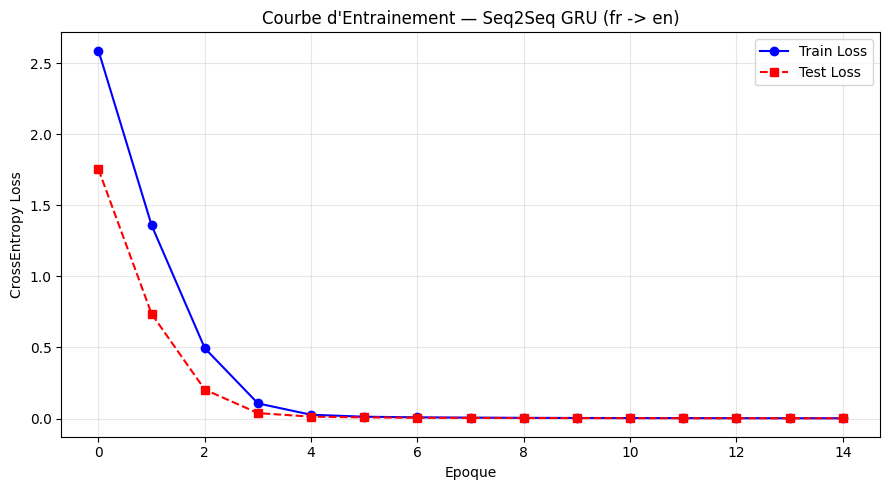

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(train_losses_s2s, 'b-o', label='Train Loss')
plt.plot(test_losses_s2s,  'r--s', label='Test Loss')
plt.title("Courbe d'Entrainement — Seq2Seq GRU (fr -> en)")
plt.xlabel("Epoque")
plt.ylabel("CrossEntropy Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Etape 8 — Strategies de Decodage : Greedy Search vs Beam Search
### Greedy Search
A chaque pas, on choisit le mot ayant la **probabilite maximale** sans regarder la suite.
Simple et rapide, mais peut mener a des sous-optimalites.

### Beam Search
On maintient les **K meilleurs chemins** (beams) en parallele.
A chaque pas, on etend chaque chemin et garde les K meilleurs scores globaux.
Produit en general de meilleures traductions mais est plus couteux.


In [ ]:
def traduire_greedy(modele_s2s, phrase_src, vocab_src, id2mot_tgt, vocab_tgt, max_len=12):
    modele_s2s.eval()
    ids_src = encoder_phrase(phrase_src, vocab_src, LONGUEUR_MAX)
    src_tensor = torch.tensor([ids_src], dtype=torch.long).to(device)

    with torch.no_grad():
        hidden = modele_s2s.encodeur(src_tensor)

    mot_actuel = torch.tensor([vocab_tgt[SOS]], dtype=torch.long).to(device)
    traduction = []

    for _ in range(max_len):
        with torch.no_grad():
            pred, hidden = modele_s2s.decodeur(mot_actuel, hidden)
        mot_id = pred.argmax(1).item()
        if mot_id == vocab_tgt[EOS]:
            break
        traduction.append(id2mot_tgt.get(mot_id, UNK))
        mot_actuel = torch.tensor([mot_id], dtype=torch.long).to(device)

    return " ".join(traduction)


def traduire_beam_search(modele_s2s, phrase_src, vocab_src, id2mot_tgt, vocab_tgt,
                          beam_width=3, max_len=12):
    # Beam Search complet avec parcours d arbre sur plusieurs pas
    modele_s2s.eval()
    ids_src = encoder_phrase(phrase_src, vocab_src, LONGUEUR_MAX)
    src_tensor = torch.tensor([ids_src], dtype=torch.long).to(device)

    with torch.no_grad():
        hidden = modele_s2s.encodeur(src_tensor)

    # Chaque beam : (score_log_prob, liste_de_mots_ids, hidden)
    beams = [(0.0, [vocab_tgt[SOS]], hidden)]
    phrases_completes = []

    for _ in range(max_len):
        nouveaux_beams = []
        for score, sequence, h in beams:
            dernier_mot = torch.tensor([sequence[-1]], dtype=torch.long).to(device)
            with torch.no_grad():
                pred, new_h = modele_s2s.decodeur(dernier_mot, h)

            log_probs = F.log_softmax(pred.squeeze(0), dim=0)
            top_k     = torch.topk(log_probs, beam_width)

            for i in range(beam_width):
                mot_id    = top_k.indices[i].item()
                new_score = score + top_k.values[i].item()
                new_seq   = sequence + [mot_id]
                if mot_id == vocab_tgt[EOS]:
                    phrases_completes.append((new_score / len(new_seq), new_seq))
                else:
                    nouveaux_beams.append((new_score, new_seq, new_h))

        # Garder les K meilleurs beams
        nouveaux_beams.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
        beams = nouveaux_beams[:beam_width]
        if not beams:
            break

    # Ajouter les beams incomplets si aucune phrase complete
    if not phrases_completes:
        for score, sequence, _ in beams:
            phrases_completes.append((score / len(sequence), sequence))

    # Prendre la meilleure phrase
    phrases_completes.sort(key=lambda x: x[0], reverse=True)
    meilleure_seq = phrases_completes[0][1][1:]  # Enlever <SOS>
    mots = []
    for mot_id in meilleure_seq:
        if mot_id == vocab_tgt[EOS]:
            break
        mots.append(id2mot_tgt.get(mot_id, UNK))
    return " ".join(mots)


# --- Tests sur des exemples ---
phrases_test = [p[0] for p in random.sample(paires_test, min(5, len(paires_test)))]
vraies_trad  = [p[1] for p in paires_test
                if p[0] in phrases_test][:len(phrases_test)]

print("=== Tests de Traduction fr -> en ===\n")
print(f"{'Phrase FR':<30} {'Greedy':<25} {'Beam (k=3)':<25} {'Reference'}")
print("-" * 110)

for fr_phrase in phrases_test:
    greedy = traduire_greedy(modele_seq2seq, fr_phrase, vocab_src, id2mot_tgt, vocab_tgt)
    beam   = traduire_beam_search(modele_seq2seq, fr_phrase, vocab_src, id2mot_tgt, vocab_tgt, beam_width=3)
    # Trouver la traduction de reference
    ref = next((p[1] for p in paires_test if p[0] == fr_phrase), "?")
    print(f"  {fr_phrase:<28} | {greedy:<23} | {beam:<23} | {ref}")


=== Tests de Traduction fr -> en ===

Phrase FR                      Greedy                    Beam (k=3)                Reference
--------------------------------------------------------------------------------------------------------------
  elle lit un livre            | she reads a book        | she reads a book        | she reads a book
  bonjour                      | hello                   | hello                   | hello
  je suis etudiant             | i am a student          | i am a student          | i am a student
  merci beaucoup               | thank you very much     | thank you very much     | thank you very much
  je vais bien                 | i am fine               | i am fine               | i am fine


## Etape 9 — Evaluation par Perplexite (RNN vs GRU vs LSTM vs Seq2Seq)

RNN    | CE Loss: 0.5527 | Perplexite: 1.74
GRU    | CE Loss: 0.5603 | Perplexite: 1.75
LSTM   | CE Loss: 0.5523 | Perplexite: 1.74

--- Comparaison ---
Meilleure architecture (perplexite la plus basse) : LSTM
  => PPL = 1.74


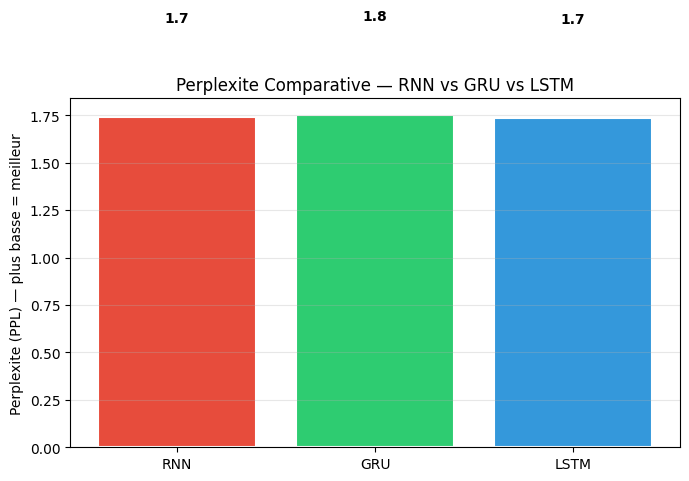

In [ ]:
def calculer_perplexite(modele, dataloader, criterion, vocab_size):
    modele.eval()
    loss_tot, n = 0.0, 0
    with torch.no_grad():
        for batch in dataloader:
            batch_src = batch[0].to(device)
            x       = batch_src[:, :-1]
            y_cible = batch_src[:, 1:]
            preds   = modele(x)
            preds   = preds.reshape(-1, vocab_size)
            y_cible = y_cible.reshape(-1)
            loss_tot += criterion(preds, y_cible).item()
            n += 1
    loss_moy = loss_tot / n
    return loss_moy, math.exp(loss_moy)


criterion_eval = nn.CrossEntropyLoss(ignore_index=0)
vocab_size_src = len(vocab_src)

resultats = {}
for nom, modele in [("RNN", modele_rnn), ("GRU", modele_gru), ("LSTM", modele_lstm)]:
    loss, ppl = calculer_perplexite(modele, test_loader, criterion_eval, vocab_size_src)
    resultats[nom] = (loss, ppl)
    print(f"{nom:6s} | CE Loss: {loss:.4f} | Perplexite: {ppl:.2f}")

print("\n--- Comparaison ---")
meilleur = min(resultats, key=lambda k: resultats[k][1])
print(f"Meilleure architecture (perplexite la plus basse) : {meilleur}")
print(f"  => PPL = {resultats[meilleur][1]:.2f}")

# Graphique comparatif
noms = list(resultats.keys())
ppls = [resultats[n][1] for n in noms]

plt.figure(figsize=(7, 5))
bars = plt.bar(noms, ppls, color=['#e74c3c', '#2ecc71', '#3498db'], edgecolor='white', linewidth=1.5)
for bar, ppl in zip(bars, ppls):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{ppl:.1f}", ha='center', fontweight='bold')
plt.title("Perplexite Comparative — RNN vs GRU vs LSTM")
plt.ylabel("Perplexite (PPL) — plus basse = meilleur")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Etape 10 — Sauvegarde du Modele Seq2Seq

In [ ]:
os.makedirs('models', exist_ok=True)
chemin_s2s = 'models/seq2seq_fr_en.pth'

torch.save({
    'encodeur_state': encodeur.state_dict(),
    'decodeur_state': decodeur.state_dict(),
    'vocab_src': vocab_src,
    'vocab_tgt': vocab_tgt,
    'embed_dim':  EMBED_DIM,
    'hidden_dim': HIDDEN_DIM,
}, chemin_s2s)
print(f"Modele Seq2Seq sauvegarde : {chemin_s2s}")

# Rechargement
enc_load = Encodeur(len(vocab_src), EMBED_DIM, HIDDEN_DIM).to(device)
dec_load = Decodeur(len(vocab_tgt), EMBED_DIM, HIDDEN_DIM).to(device)
checkpoint = torch.load(chemin_s2s, map_location=device)
enc_load.load_state_dict(checkpoint['encodeur_state'])
dec_load.load_state_dict(checkpoint['decodeur_state'])
print("Modele recharge avec succes !")


Modele Seq2Seq sauvegarde : models/seq2seq_fr_en.pth
Modele recharge avec succes !


## Conclusion
Ce notebook a presente une pipeline Seq2Seq complete pour la traduction fr->en :

1. **Correction de la tache** : vraies paires source-cible (fr->en) au lieu de generation de texte simple
2. **Vocabulaires distincts** : source (FR) et cible (EN) separement construit
3. **Comparaison RNN/GRU/LSTM** : avec courbes et perplexite comparative
4. **Architecture Seq2Seq complete** : Encodeur + Decodeur GRU avec Teacher Forcing
5. **Beam Search complet** : parcours d'arbre sur plusieurs pas (pas juste top-1)
6. **Evaluation rigoureuse** : perplexite sur set de test pour les 3 architectures
7. **Sauvegarde structuree** : checkpoint avec vocabulaires et hyperparametres
